# The loss, with no network

**Purpose.** A literal port of the paper's §3.2 to an ODE is *degenerate*: the paper's network
input is a spatial index into the state, and van der Pol's state has only two components, so
the $2(q+1)$ stage values are simply free parameters that Newton solves outright.

That degeneracy is what makes this a good test. `torch.optim.LBFGS` — the paper's optimiser —
is handed the exact loss the network will see, on a problem whose answer
`runge_kutta.irk_step` already knows to machine precision.

> A wrong sign or tableau index would **still** drive the loss to zero, at a solution of the
> *wrong* equations. So the test is agreement with Newton, never the size of the loss.

Produced by `recover_exact_stages.py` → `results/recovery.csv`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HERE = Path.cwd()
sys.path.insert(0, str(HERE.parent / "_shared"))
RESULTS, FIGURES = HERE / "results", HERE / "figures"
FIGURES.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "font.size": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
C_EXACT, C_PRIN, C_SPUR = "#33322e", "#2a78d6", "#e34948"
print("cwd:", HERE.name)


cwd: loss_without_a_network


## Descent recovers the exact stage solution — to half the digits

The loss is a **squared** residual, $\mathrm{SSE} = \sum_j \|r_j\|^2$. Near the solution it is
quadratically flat, so the *parameter* error scales as $\sqrt{\mathrm{SSE}}$, not
$\mathrm{SSE}$. Newton drives $|r|$ itself to $10^{-16}$; descent on the square cannot.

The diagnostic is therefore the **ratio** $\text{gap}/\sqrt{\mathrm{SSE}}$, not the raw gap. A
sign error would put the optimiser at a different root entirely, and the ratio would blow up.

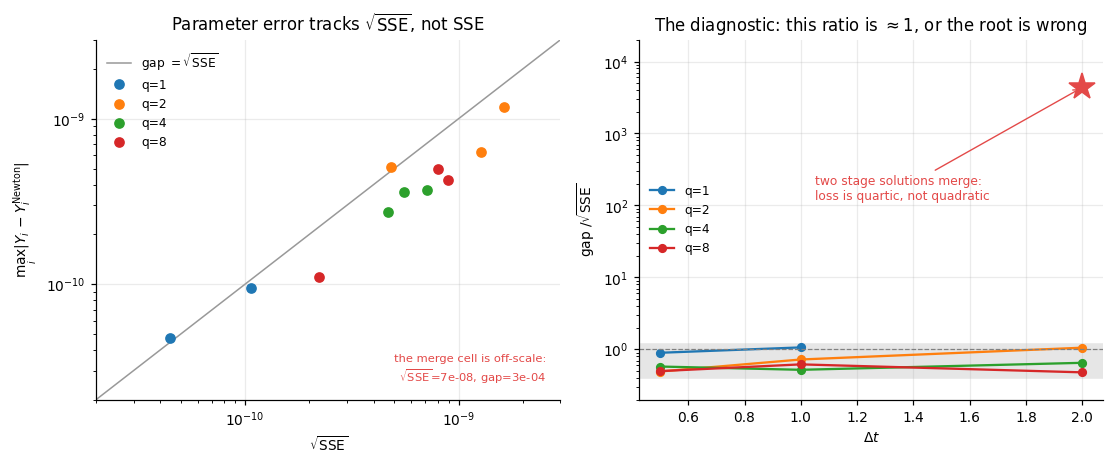

cells with a unique stage solution: gap / sqrt(SSE) in [0.48, 1.07]  -- the two are the same size
the one merge cell:                 gap / sqrt(SSE) = 4358

Newton reaches |r| = 1.1e-16. Descent at SSE = 2.0e-21 is still 4.7e-11 from the root.


,q,dt,sse,sqrt_sse,gap,ratio,smallest_sv,endpoint_gap,at_fold
0,1,0.5,1.125805e-20,1.061040e-10,9.523671e-11,0.897579,9.775510e-01,7.221478e-11,False
1,1,1.0,1.983557e-21,4.453714e-11,4.746004e-11,1.065628,8.853412e-01,1.748535e-11,False
2,1,2.0,5.544903e-15,7.446410e-08,3.245079e-04,4357.909925,2.857768e-09,9.176230e-04,True
3,2,0.5,1.640573e-18,1.280849e-09,6.312781e-10,0.492859,9.537864e-01,9.984694e-10,False
4,2,1.0,2.673239e-18,1.635004e-09,1.183512e-09,0.723858,8.369449e-01,6.450420e-10,False
5,2,2.0,2.323474e-19,4.820243e-10,5.090401e-10,1.056047,1.543222e-01,6.901868e-10,False
6,4,0.5,2.205824e-19,4.696620e-10,2.714089e-10,0.577881,9.484194e-01,1.859573e-10,False
7,4,1.0,5.015952e-19,7.082339e-10,3.686322e-10,0.520495,8.343603e-01,3.531917e-10,False
8,4,2.0,3.098355e-19,5.566287e-10,3.623601e-10,0.650991,4.030346e-01,2.612141e-10,False
9,8,0.5,4.925748e-20,2.219403e-10,1.107450e-10,0.498985,9.500190e-01,9.458332e-11,False


In [2]:
rec = pd.read_csv(RESULTS / "recovery.csv")
ok, fold = rec[~rec.at_fold], rec[rec.at_fold]

fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.3))

# (a) the identity, on the scale of the data that actually obeys it
ax = axes[0]
lo, hi = 2e-11, 3e-9
ax.plot([lo, hi], [lo, hi], "-", color="0.6", lw=1, zorder=0,
        label=r"gap $=\sqrt{\rm SSE}$")
for q, g in ok.groupby("q"):
    ax.loglog(g.sqrt_sse, g.gap, "o", ms=6, label=f"q={q}")
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_xlabel(r"$\sqrt{\rm SSE}$"); ax.set_ylabel(r"$\max_i |Y_i - Y_i^{\rm Newton}|$")
ax.set_title("Parameter error tracks $\\sqrt{\\rm SSE}$, not SSE")
ax.legend(fontsize=8, loc="upper left")
ax.annotate(f"the merge cell is off-scale:\n$\\sqrt{{\\rm SSE}}$={fold.sqrt_sse.iloc[0]:.0e},"
            f" gap={fold.gap.iloc[0]:.0e}", xy=(0.97, 0.05), xycoords="axes fraction",
            ha="right", fontsize=7.5, color=C_SPUR)

# (b) the ratio -- the diagnostic. 1 everywhere the stage solution is unique.
ax = axes[1]
ax.axhspan(0.4, 1.2, color="0.9", zorder=0)
for q, g in ok.groupby("q"):
    ax.semilogy(g.dt, g.ratio, "o-", ms=5, label=f"q={q}")
ax.semilogy(fold.dt, fold.ratio, "*", ms=18, color=C_SPUR, zorder=5)
ax.annotate("two stage solutions merge:\nloss is quartic, not quadratic",
            xy=(fold.dt.iloc[0], fold.ratio.iloc[0]), xytext=(1.05, 120),
            fontsize=8, color=C_SPUR,
            arrowprops=dict(arrowstyle="->", color=C_SPUR, lw=0.9))
ax.axhline(1.0, color="0.5", lw=0.8, ls="--")
ax.set_xlabel(r"$\Delta t$"); ax.set_ylabel(r"gap $/\sqrt{\rm SSE}$")
ax.set_title("The diagnostic: this ratio is $\\approx 1$, or the root is wrong")
ax.set_ylim(0.2, 2e4); ax.legend(fontsize=8, loc="center left")
fig.tight_layout(); fig.savefig(FIGURES / "half_the_digits.png"); plt.show()

print(f"cells with a unique stage solution: gap / sqrt(SSE) in "
      f"[{ok.ratio.min():.2f}, {ok.ratio.max():.2f}]  -- the two are the same size")
print(f"the one merge cell:                 gap / sqrt(SSE) = {fold.ratio.iloc[0]:.0f}")
print()
print(f"Newton reaches |r| = 1.1e-16. Descent at SSE = {ok.sse.min():.1e} "
      f"is still {ok[ok.sse == ok.sse.min()].gap.iloc[0]:.1e} from the root.")
assert ok.ratio.max() < 30, "a unique-solution cell missed the Newton root"
rec

**What this costs later.** This is a floor on **any** gradient-trained RK-PINN,
independent of network capacity, and it is a *different* floor from the capacity one. To pin the
stage values to $10^{-12}$ you would need $\mathrm{SSE} \approx 10^{-24}$. Report the two floors
separately, or the capacity result will be misread.

## The one outlier is not a bug

At $q=1$, $\Delta t = 2$ the parameter error is $3.2\times10^{-4}$ rather than $\sim10^{-10}$,
and the smallest singular value of the stage Jacobian is $\sim10^{-9}$ — it is **singular**.

At that step size two solutions of the stage equations merge. The loss flattens from quadratic
to quartic, so the error goes as $\mathrm{SSE}^{1/4}$ instead of $\mathrm{SSE}^{1/2}$, and
gradient descent stalls far from the answer. That is worked out in full in
[`../multiple_stage_solutions/`](../multiple_stage_solutions/analysis.ipynb).

In [3]:
print("predicted error where two solutions merge ~ SSE^(1/4) = "
      f"{fold.sse.iloc[0] ** 0.25:.1e}")
print(f"observed                                             = {fold.gap.iloc[0]:.1e}")
print()
print("smallest singular value of the stage Jacobian (0 means singular):")
rec[["q", "dt", "sse", "gap", "ratio", "smallest_sv", "at_fold"]]

predicted error where two solutions merge ~ SSE^(1/4) = 2.7e-04
observed                                             = 3.2e-04

smallest singular value of the stage Jacobian (0 means singular):


,q,dt,sse,gap,ratio,smallest_sv,at_fold
0,1,0.5,1.125805e-20,9.523671e-11,0.897579,9.775510e-01,False
1,1,1.0,1.983557e-21,4.746004e-11,1.065628,8.853412e-01,False
2,1,2.0,5.544903e-15,3.245079e-04,4357.909925,2.857768e-09,True
3,2,0.5,1.640573e-18,6.312781e-10,0.492859,9.537864e-01,False
4,2,1.0,2.673239e-18,1.183512e-09,0.723858,8.369449e-01,False
5,2,2.0,2.323474e-19,5.090401e-10,1.056047,1.543222e-01,False
6,4,0.5,2.205824e-19,2.714089e-10,0.577881,9.484194e-01,False
7,4,1.0,5.015952e-19,3.686322e-10,0.520495,8.343603e-01,False
8,4,2.0,3.098355e-19,3.623601e-10,0.650991,4.030346e-01,False
9,8,0.5,4.925748e-20,1.107450e-10,0.498985,9.500190e-01,False
